# Pandas Practice 3 (Bike Share Data)

As a data scientist, you don't always have to invent the wheel from scratch. The great advantage of Python is that smart people before you spend a lot of energy on making life easier for the next programers. So please, make your life easier and use code that has already been implemented, don't call it "copying" but "friendly borrowing" of other people's code. If you copy whole functions or great graphs in the future, don't forget to give props to the inventor!

So for this exercise, too, if you get stuck at any point, look at good solutions from others and learn a lot from them about how to solve these problems even better.
Here are two good resources for small code snippet which can be very helpful when dealing with DataFrames:

- [Sebastian Raschkas "Things in Pandas I Wish I'd Known Earlier"](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb)
- [Helpful Python Code Snippets for Data Exploration in Pandas](https://medium.com/@msalmon00/helpful-python-code-snippets-for-data-exploration-in-pandas-b7c5aed5ecb9)
- [Manipulating tabular data with Pandas](https://neuroimaging-data-science.org/content/004-scipy/002-pandas.html)


**By the end of this session you should be able to**
- Explore data with Pandas to answer conceptual questions
- Write chained commands for efficient one-liners



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    _cols = df.columns
    _lower_case_cols = map(str.lower, _cols)
    _clean_cols = [c.replace(" ", "_").replace("#", "num") for c in _lower_case_cols]
    df_out = df.copy()
    df_out.columns = _clean_cols
    return df_out

In [3]:
df = (pd
      .read_csv('data/bike_share_201402_trip_data.csv')
      .pipe(clean_column_names)
      )

In [4]:
df.head()

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


How many observations are there?

In [5]:
_n_rows, _n_cols = df.shape
print(f"There are {_n_rows} rows, i.e., observations and {_n_cols} columns")

There are 144015 rows, i.e., observations and 11 columns


Change the columns to be pythonic:

- lowercase 
- replace " " with `_` as a separator
- replace "#" with `num` 


In [6]:
# see `clean_column_names()`
df.columns

Index(['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal',
       'end_date', 'end_station', 'end_terminal', 'bike_num',
       'subscription_type', 'zip_code'],
      dtype='str')

How many types of subscription options are there? What are the different subscription types?

In [7]:
_subs_types = df.subscription_type 
print(f"""
There are {_subs_types.nunique()} different subscription options:
{list(_subs_types.unique())!r}
""")


There are 2 different subscription options:
['Subscriber', 'Customer']



What is the frequency of each subscription option?

In [8]:
_subs_types.value_counts()

subscription_type
Subscriber    113647
Customer       30368
Name: count, dtype: int64

In [9]:
from collections import Counter
c = Counter(_subs_types)
for k,v in c.items():
    print(f"{k}: {v:,}")

Subscriber: 113,647
Customer: 30,368


Please plot the frequency of each subscription option with a pie chart:

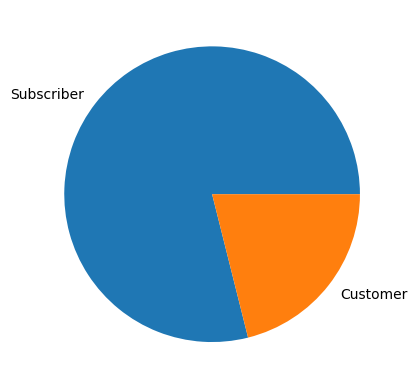

In [10]:
# _ = plt.pie(c.values(), labels=c.keys())
_ = (df
     .subscription_type
     .value_counts()
     .plot.pie()
     )

Please plot the frequency of each subscription option with a bar chart:

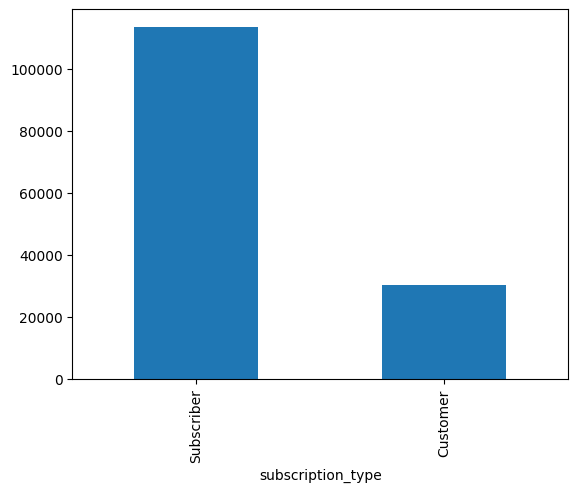

In [11]:
_ = (df
     .subscription_type
     .value_counts()
     .plot.bar()
     )

Have a look at the start_station column: Which 10 stations occur most frequently?

In [12]:
(df
 .start_station
 .value_counts()
 .sort_values(ascending=False)
 .head(10)
)

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

Now look at the end_station column: Which 10 stations occur the least often?

In [13]:
(df
 .end_station
 .value_counts()
 .sort_values()
 .head(10)
 )

end_station
Mezes Park                            5
San Jose Government Center           23
Broadway at Main                     56
San Antonio Shopping Center          93
Franklin at Maple                    93
San Mateo County Center             106
Redwood City Public Library         117
Castro Street and El Camino Real    129
Redwood City Medical Center         178
Broadway St at Battery St           205
Name: count, dtype: int64

Create a table that has start_station segmented by subscription_type and include also the row/column margins (subtotals). If you are not sure how to do it, check out the documentation for `pd.crosstab()`.

In [35]:
df_ctab = pd.crosstab(df.start_station, df.subscription_type, margins=True)
df_ctab

subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


In [39]:
df_ctab_norm = pd.crosstab(df.start_station, df.subscription_type, margins=True, normalize=True)
df_ctab_norm.div(df_ctab_norm.All, axis=0)

subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,0.113083,0.886917,1.0
2nd at South Park,0.120009,0.879991,1.0
2nd at Townsend,0.176860,0.823140,1.0
5th at Howard,0.229981,0.770019,1.0
Adobe on Almaden,0.223881,0.776119,1.0
...,...,...,...
Townsend at 7th,0.115290,0.884710,1.0
University and Emerson,0.755760,0.244240,1.0
Washington at Kearney,0.381114,0.618886,1.0


In [ ]:
val_counts = df.start_station.value_counts()
df_ctab.div(val_counts, axis=0)

subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,0.113083,0.886917,1.0
2nd at South Park,0.120009,0.879991,1.0
2nd at Townsend,0.176860,0.823140,1.0
5th at Howard,0.229981,0.770019,1.0
Adobe on Almaden,0.223881,0.776119,1.0
...,...,...,...
Temporary Transbay Terminal (Howard at Beale),0.083513,0.916487,1.0
Townsend at 7th,0.115290,0.884710,1.0
University and Emerson,0.755760,0.244240,1.0


Let's look at the duration... Which unit do you think is used here?

How long is the shortest trip? How many are that short?

In [46]:
print("looking at duration, start_date and end_date, it is clear that unit for `duration` is `seconds` ")
df[["start_date", "end_date", "duration", ]].head(10)

looking at duration, start_date and end_date, it is clear that unit for `duration` is `seconds` 


,start_date,end_date,duration
0,8/29/2013 14:13,8/29/2013 14:14,63
1,8/29/2013 14:42,8/29/2013 14:43,70
2,8/29/2013 10:16,8/29/2013 10:17,71
3,8/29/2013 11:29,8/29/2013 11:30,77
4,8/29/2013 12:02,8/29/2013 12:04,83
5,8/29/2013 18:54,8/29/2013 18:56,103
6,8/29/2013 13:25,8/29/2013 13:27,109
7,8/29/2013 14:02,8/29/2013 14:04,111
8,8/29/2013 17:01,8/29/2013 17:03,113
9,8/29/2013 11:33,8/29/2013 11:35,114


What do you think is going on with the short trips?

In [ ]:
print("short trips, seem to be cancelled trips, possibly due to technical problems")

short trips, seem to be cancelled trips, possibly due to technical problems


What is the longest trip?

In [66]:
max_duration_sec = df.duration.max()
max_duration_td = pd.Timedelta(seconds=max_duration_sec)
print(f"The longest trip lasted {max_duration_td}")

The longest trip lasted 8 days 08:37:16


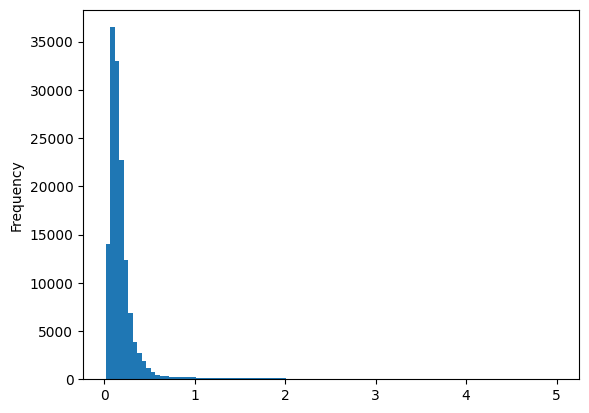

In [91]:
_ = df.query(f"duration <= {5 * 3600}").duration.div(3600).plot.hist(bins=100)

How would you define a "long" trip? How many trips are "long" according to your definition?

In [114]:
duration_treshold_h = 5
df_long_trips = df.query(f"duration > {duration_treshold_h * 3600}")
n_long_trips, _ = df_long_trips.shape
total_trips, _ = df.shape
long_trip_ratio = n_long_trips / total_trips

print(f"""
Looking at some histograms of the duration 
and given that this is a conventional urban 
bike sharing service, I'd define 'long' as 
a trip lasting more than {duration_treshold_h} hours.

By this definition, there are 
  {n_long_trips:,} long trips out of
{total_trips:,} ({long_trip_ratio:0.2%})
""")


Looking at some histograms of the duration 
and given that this is a conventional urban 
bike sharing service, I'd define 'long' as 
a trip lasting more than 5 hours.

By this definition, there are 
  1,123 long trips out of
144,015 (0.78%)



Do the long durations seem reasonable? Why are they so long? What could it tell us about the users?

In [117]:
print("""
The long trips do not seem reasonable to me."
The user could be borrowing the bikes for several days in order to 'reserve' them / daily use
""")


The long trips do not seem reasonable to me."
The user could be borrowing the bikes for several days in order to 'reserve' them / daily use



Plot the duration column.

(0.0, 5.0)

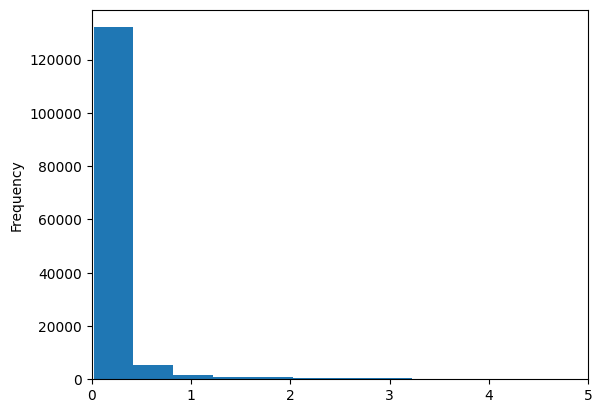

In [ ]:
_ = df.duration.div(3600).plot.hist(bins=500)
plt.xlim([0,5])

Does this plot give any insights?

In [161]:
print("no insight...")

no insight...


Select subsections of the data to make plots that provide more insights.

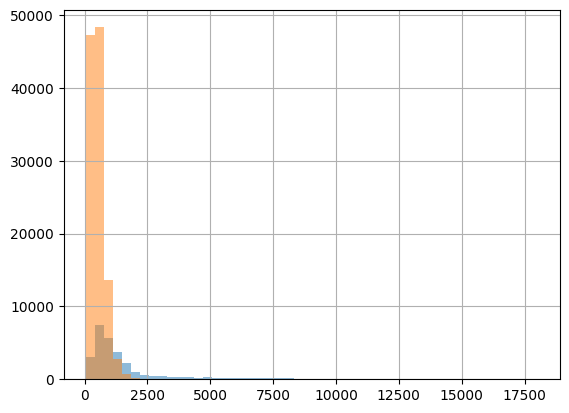

In [181]:
_ = (df
     .query(f"duration < {duration_treshold_h * 3600}")
     .groupby("subscription_type")
     .duration.hist(bins=50, alpha=.5)
     )


The Product Team would like all of the station names to be lower case and  with `_` as a separator

`South Van Ness at Market` -> `south_van_ness_at_market`  

**DO NOT USE A FOR LOOP. THEY ARE THE 👿**

In [144]:
def snake_caseify_series(s: pd.Series) -> pd.Series:
    return (s.str.lower()
    # 1. Replace all non-alphanumeric chars with a space
    .str.replace(r"[^\w\s]", " ", regex=True)
    .str.strip()
    # 2. Replace one or more whitespace chunks with a single underscore
    .str.replace(r"\s+", "_", regex=True)
    )
    
snake_caseify_series(df.start_station)

0                south_van_ness_at_market
1                      san_jose_city_hall
2                 mountain_view_city_hall
3                      san_jose_city_hall
4                south_van_ness_at_market
                       ...               
144010                 powell_street_bart
144011           commercial_at_montgomery
144012             embarcadero_at_sansome
144013    civic_center_bart_7th_at_market
144014                  2nd_at_south_park
Name: start_station, Length: 144015, dtype: str

Now take a timer and set it to 15 minutes. Take this time to explore the data guided by your own intuition or hypotheses…
> Time boxing is a helpful approach when working with a new dataset so you won't fall into any rabbit holes. 